# Следующий шаг после базового анализа: учебный AI-прогноз финансового параметра

## Что мы делаем в этом ноутбуке

В предыдущем ноутбуке мы выполняли **анализ реального финансового датасета**.  
Теперь мы добавляем в проект обязательный AI-компонент — **прогнозирование**.

## Какой параметр мы прогнозируем

В качестве прогнозируемого параметра я выбрал **5-дневную скользящую среднюю по `adjusted`**.  
В ноутбуке этот показатель будет называться `ma_5_adjusted`.

## Почему выбран именно такой параметр

Для начинающих разработчиков это хороший учебный выбор, потому что:

- он строится на основе реальных финансовых данных из датасета;
- он связан с ценой акции, а значит остаётся понятным экономически;
- он **менее шумный**, чем сырая дневная цена;
- его проще прогнозировать и объяснять в дипломном проекте.

## Где здесь ИИ

Мы используем модель **машинного обучения** `LinearRegression`.

В учебном смысле это уже AI/ML-подход, потому что модель:

- получает исторические данные;
- обучается на примерах;
- строит прогноз для будущих значений;
- оценивается по метрикам качества.

## Что важно понять студенту

После выполнения этого ноутбука студент должен понимать:

- как поставить задачу прогноза;
- как выбрать целевую переменную;
- как подготовить признаки для ML-модели;
- как честно проверить качество модели;
- как визуализировать прогноз;
- как описать использование ИИ в дипломном проекте.

> Важно: это учебный пример использования ИИ в финансовом анализе.  
> Он не является инвестиционной рекомендацией.

## Практическая ячейка 1. Импорт библиотек и загрузка исходных данных

### Назначение ячейки

Эта ячейка:

- подключает библиотеки для работы с таблицами, графиками и ML;
- загружает датасет из интернета;
- при отсутствии интернета использует локальную копию файла;
- подготавливает столбцы `Date` и `adjusted`.

### Краткая теория

Любой проект с ИИ начинается с данных.  
Если данные загружены некорректно, модель будет обучаться неправильно.

Для этого ноутбука нам нужны:

- `pandas` — работа с таблицами;
- `matplotlib` — построение графиков;
- `scikit-learn` — машинное обучение и метрики качества.

### Как интерпретировать результат

После запуска ячейки посмотрите:

- откуда были загружены данные;
- сколько строк оказалось в таблице;
- как выглядят первые записи;
- правильно ли прочиталась дата.

Это базовая проверка перед любым ML-анализом.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dataset_url = "https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv"
local_candidates = [
    "finance-charts-apple.csv",
    "./finance-charts-apple.csv",
    "/mnt/data/finance-charts-apple.csv"
]

try:
    raw_df = pd.read_csv(dataset_url)
    data_source = f"Данные загружены из интернета: {dataset_url}"
except Exception:
    loaded = False
    for candidate in local_candidates:
        if Path(candidate).exists():
            raw_df = pd.read_csv(candidate)
            data_source = f"Интернет недоступен, загружена локальная копия: {candidate}"
            loaded = True
            break
    if not loaded:
        raise FileNotFoundError("Не удалось загрузить исходный датасет.")

rename_map = {
    "AAPL.Open": "open",
    "AAPL.High": "high",
    "AAPL.Low": "low",
    "AAPL.Close": "close",
    "AAPL.Volume": "volume",
    "AAPL.Adjusted": "adjusted"
}

df = raw_df.rename(columns=rename_map).copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

base_df = df[["Date", "adjusted"]].copy()

print(data_source)
print("Размер таблицы:", base_df.shape)
print("Период наблюдений:", base_df["Date"].min().date(), "—", base_df["Date"].max().date())
display(base_df.head())

Данные загружены из интернета: https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv
Размер таблицы: (506, 2)
Период наблюдений: 2015-02-17 — 2017-02-16


,Date,adjusted
0,2015-02-17,122.905254
1,2015-02-18,123.760965
2,2015-02-19,123.501363
3,2015-02-20,124.510914
4,2015-02-23,127.876074


## Практическая ячейка 2. Формирование прогнозируемого параметра и постановка задачи

### Назначение ячейки

В этой ячейке мы:

- создаём новый показатель `ma_5_adjusted`;
- строим график исходной цены и сглаженной линии;
- формулируем задачу прогноза.

### Краткая теория

**Скользящая средняя** — это усреднение значения за несколько последних дней.  
В нашем случае окно равно 5 дням.

Зачем это нужно:

- ряд становится более гладким;
- случайный шум уменьшается;
- общий тренд видно лучше;
- новичку проще понять, что именно предсказывает модель.

### Как интерпретировать результат

На графике вы увидите две линии:

- исходную `adjusted` — более «нервную»;
- сглаженную `ma_5_adjusted` — более плавную.

Именно вторую линию мы будем прогнозировать.

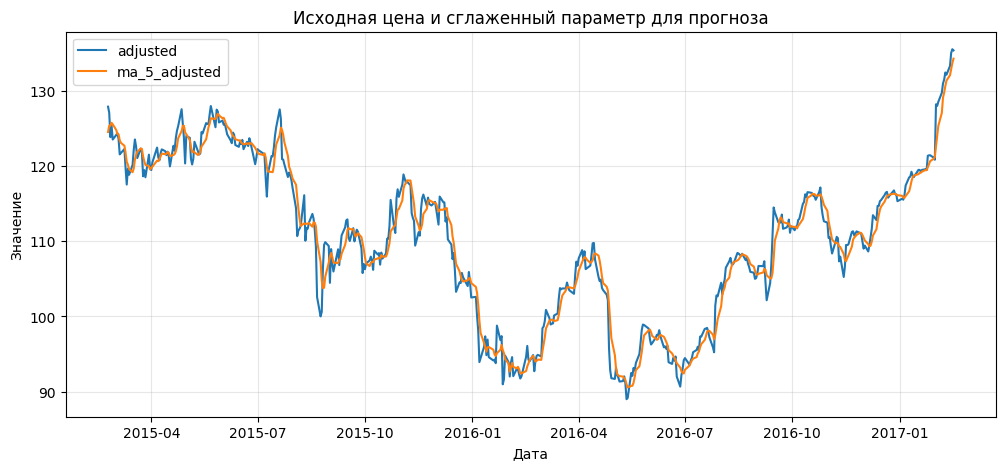

Мы будем прогнозировать следующий день для параметра ma_5_adjusted.


,Date,adjusted,ma_5_adjusted
0,2015-02-23,127.876,124.511
1,2015-02-24,127.078,125.345
2,2015-02-25,123.828,125.359
3,2015-02-26,125.395,125.738
4,2015-02-27,123.511,125.538
5,2015-03-02,124.117,124.786
6,2015-03-03,124.376,124.246
7,2015-03-04,123.588,124.197
8,2015-03-05,121.540,123.426
9,2015-03-06,121.723,123.069


In [ ]:
forecast_df = base_df.copy()
forecast_df["ma_5_adjusted"] = forecast_df["adjusted"].rolling(window=5).mean()
forecast_df = forecast_df.dropna().reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(forecast_df["Date"], forecast_df["adjusted"], label="adjusted")
plt.plot(forecast_df["Date"], forecast_df["ma_5_adjusted"], label="ma_5_adjusted")
plt.title("Исходная цена и сглаженный параметр для прогноза")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Мы будем прогнозировать следующий день для параметра ma_5_adjusted.")
display(forecast_df[["Date", "adjusted", "ma_5_adjusted"]].head(10).round(3))

## Практическая ячейка 3. Создание признаков для модели машинного обучения

### Назначение ячейки

Теперь мы готовим таблицу признаков для модели.  
Мы создадим:

- текущее значение `ma_5_adjusted`;
- лаги за предыдущие дни;
- короткие скользящие статистики;
- целевую переменную `target_next_day`.

### Краткая теория

Модель не «понимает время» автоматически.  
Поэтому мы вручную передаём ей информацию о прошлом.

Такие признаки называются **лаговыми**:

- `lag_1` — значение вчера;
- `lag_2` — значение позавчера;
- `lag_3` — значение три дня назад;
- `lag_5` — значение пять дней назад.

Также мы добавим:

- `ma_3` — среднее за 3 дня;
- `std_3` — изменчивость за 3 дня;
- `ma_7` — среднее за 7 дней;
- `std_7` — изменчивость за 7 дней.

### Как интерпретировать результат

После запуска посмотрите:

- появились ли новые столбцы;
- есть ли у целевой переменной смысл;
- исчезли ли пропуски после `dropna()`.

Если таблица готова, можно переходить к обучению модели.

In [ ]:
model_df = forecast_df[["Date", "ma_5_adjusted"]].copy()

model_df["current_value"] = model_df["ma_5_adjusted"]
model_df["lag_1"] = model_df["ma_5_adjusted"].shift(1)
model_df["lag_2"] = model_df["ma_5_adjusted"].shift(2)
model_df["lag_3"] = model_df["ma_5_adjusted"].shift(3)
model_df["lag_5"] = model_df["ma_5_adjusted"].shift(5)
model_df["ma_3"] = model_df["ma_5_adjusted"].rolling(window=3).mean()
model_df["std_3"] = model_df["ma_5_adjusted"].rolling(window=3).std()
model_df["ma_7"] = model_df["ma_5_adjusted"].rolling(window=7).mean()
model_df["std_7"] = model_df["ma_5_adjusted"].rolling(window=7).std()
model_df["target_next_day"] = model_df["ma_5_adjusted"].shift(-1)

feature_cols = [
    "current_value", "lag_1", "lag_2", "lag_3", "lag_5",
    "ma_3", "std_3", "ma_7", "std_7"
]

prepared_df = model_df.dropna().reset_index(drop=True)

print("Размер таблицы для обучения:", prepared_df.shape)
display(prepared_df[["Date"] + feature_cols + ["target_next_day"]].head(10).round(3))

print("Количество пропусков после подготовки:")
print(prepared_df[feature_cols + ["target_next_day"]].isna().sum())

Размер таблицы для обучения: (495, 12)


,Date,current_value,lag_1,lag_2,lag_3,lag_5,ma_3,std_3,ma_7,std_7,target_next_day
0,2015-03-03,124.246,124.786,125.538,125.738,125.345,124.856,0.649,125.075,0.562,124.197
1,2015-03-04,124.197,124.246,124.786,125.538,125.359,124.410,0.327,125.030,0.624,123.426
2,2015-03-05,123.426,124.197,124.246,124.786,125.738,123.956,0.460,124.756,0.845,123.069
3,2015-03-06,123.069,123.426,124.197,124.246,125.538,123.564,0.577,124.429,1.001,122.694
4,2015-03-09,122.694,123.069,123.426,124.197,124.786,123.063,0.366,123.994,0.999,121.761
5,2015-03-10,121.761,122.694,123.069,123.426,124.246,122.508,0.673,123.454,1.045,120.550
6,2015-03-11,120.550,121.761,122.694,123.069,124.197,121.668,1.075,122.849,1.332,120.173
7,2015-03-12,120.173,120.550,121.761,122.694,123.426,120.828,0.830,122.267,1.499,119.594
8,2015-03-13,119.594,120.173,120.550,121.761,123.069,120.105,0.481,121.609,1.521,119.173
9,2015-03-16,119.173,119.594,120.173,120.550,122.694,119.646,0.502,121.002,1.524,119.659


Количество пропусков после подготовки:
current_value      0
lag_1              0
lag_2              0
lag_3              0
lag_5              0
ma_3               0
std_3              0
ma_7               0
std_7              0
target_next_day    0
dtype: int64


## Практическая ячейка 4. Хронологическое разделение и baseline

### Назначение ячейки

В этой ячейке мы:

- делим данные на train и test;
- делаем это строго по времени;
- создаём baseline-прогноз для сравнения.

### Краткая теория

Во временных рядах нельзя случайно перемешивать строки.  
Причина: в реальной жизни модель должна учиться на прошлом и проверяться на будущем.

Поэтому мы делим данные так:

- первые 80% строк — обучение;
- последние 20% строк — тест.

Baseline нужен, чтобы понять:  
дала ли ML-модель пользу по сравнению с очень простым подходом.

### Как интерпретировать результат

Мы используем baseline:

> значение следующего дня равно текущему значению.

Если ML-модель окажется лучше baseline, значит обучение действительно принесло пользу.

In [ ]:
X = prepared_df[feature_cols].copy()
y = prepared_df["target_next_day"].copy()
dates = prepared_df["Date"].copy()

split_index = int(len(prepared_df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()
dates_test = dates.iloc[split_index:].copy()

baseline_pred = X_test["current_value"]

print("Размер train:", X_train.shape)
print("Размер test :", X_test.shape)
print("Тестовый период:", dates_test.min().date(), "—", dates_test.max().date())
display(X_train.head().round(3))

Размер train: (396, 9)
Размер test : (99, 9)
Тестовый период: 2016-09-26 — 2017-02-15


,current_value,lag_1,lag_2,lag_3,lag_5,ma_3,std_3,ma_7,std_7
0,124.246,124.786,125.538,125.738,125.345,124.856,0.649,125.075,0.562
1,124.197,124.246,124.786,125.538,125.359,124.410,0.327,125.030,0.624
2,123.426,124.197,124.246,124.786,125.738,123.956,0.460,124.756,0.845
3,123.069,123.426,124.197,124.246,125.538,123.564,0.577,124.429,1.001
4,122.694,123.069,123.426,124.197,124.786,123.063,0.366,123.994,0.999


## Практическая ячейка 5. Обучение AI-модели и сравнение с baseline

### Назначение ячейки

Здесь мы:

- обучаем модель `LinearRegression`;
- делаем прогноз на тестовой части;
- рассчитываем метрики качества;
- сравниваем результат модели с baseline.

### Краткая теория

`LinearRegression` — это одна из базовых моделей машинного обучения.  
Она ищет зависимость между признаками и целевой переменной.

Мы используем три важные метрики:

- **MAE** — средняя абсолютная ошибка;
- **RMSE** — ошибка, сильнее наказывающая крупные промахи;
- **R²** — мера того, насколько хорошо модель объясняет данные.

### Как интерпретировать результат

Нам особенно важно сравнить две строки:

- baseline;
- LinearRegression.

Если ошибки у ML-модели меньше, чем у baseline, значит модель действительно научилась использовать структуру данных.

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

test_pred = model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5
baseline_r2 = r2_score(y_test, baseline_pred)

model_mae = mean_absolute_error(y_test, test_pred)
model_rmse = mean_squared_error(y_test, test_pred) ** 0.5
model_r2 = r2_score(y_test, test_pred)

metrics_df = pd.DataFrame({
    "Модель": ["Baseline", "LinearRegression"],
    "MAE": [baseline_mae, model_mae],
    "RMSE": [baseline_rmse, model_rmse],
    "R2": [baseline_r2, model_r2]
})

coef_df = pd.DataFrame({
    "Признак": feature_cols,
    "Коэффициент": model.coef_
}).sort_values("Коэффициент", key=lambda s: s.abs(), ascending=False)

print("Сравнение baseline и ML-модели:")
display(metrics_df.round(4))

print("Коэффициенты модели:")
display(coef_df.round(4))

Сравнение baseline и ML-модели:


,Модель,MAE,RMSE,R2
0,Baseline,0.4711,0.6180,0.9901
1,LinearRegression,0.2351,0.3174,0.9974


Коэффициенты модели:


,Признак,Коэффициент
7,ma_7,-2.8188
0,current_value,2.1177
4,lag_5,1.2249
1,lag_1,-0.7567
5,ma_3,0.5512
3,lag_3,0.3851
2,lag_2,0.2925
6,std_3,-0.0331
8,std_7,0.0140


## Практическая ячейка 6. Визуальная проверка качества прогноза

### Назначение ячейки

В этой ячейке мы:

- рисуем график факта и прогноза;
- строим график ошибки;
- показываем таблицу с первыми результатами теста.

### Краткая теория

Даже если метрики хорошие, график всё равно нужен.  
Он помогает увидеть:

- следует ли прогноз за реальной линией;
- есть ли заметное запаздывание;
- появляются ли крупные ошибки на отдельных участках.

### Как интерпретировать результат

На первом графике:

- чем ближе линии, тем лучше модель.

На втором графике:

- значения около нуля — это хорошо;
- крупные пики — зоны слабого прогноза.

Именно так аналитик проверяет, можно ли доверять модели хотя бы в учебном смысле.

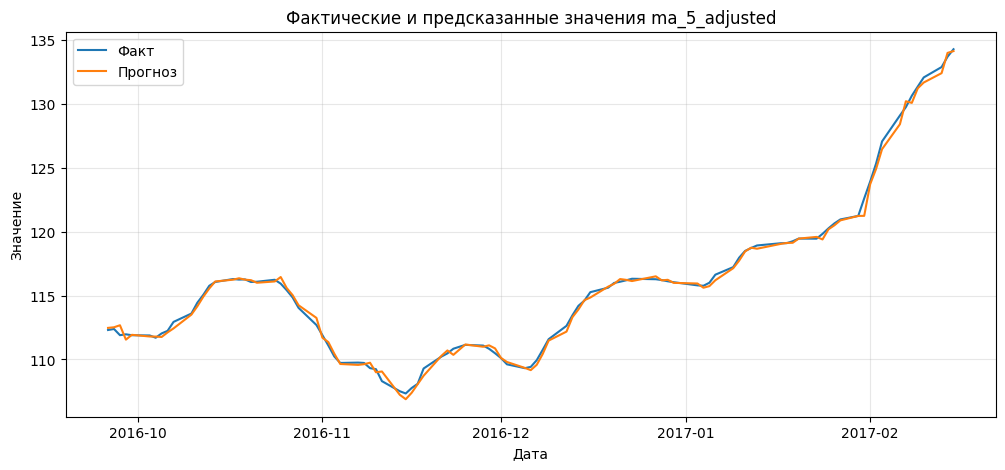

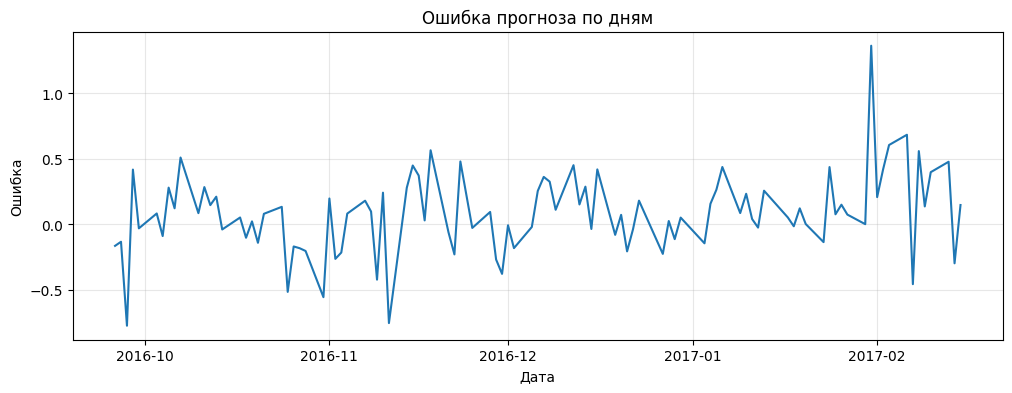

,Date,actual,predicted,error
0,2016-09-26,112.3040,112.4698,-0.1658
1,2016-09-27,112.3832,112.5177,-0.1345
2,2016-09-28,111.8998,112.6759,-0.7761
3,2016-09-29,111.9672,111.5501,0.4171
4,2016-09-30,111.8959,111.9278,-0.0320
5,2016-10-03,111.8780,111.7964,0.0817
6,2016-10-04,111.6997,111.7907,-0.0910
7,2016-10-05,112.0385,111.7593,0.2792
8,2016-10-06,112.2386,112.1174,0.1212
9,2016-10-07,112.9380,112.4287,0.5093


In [ ]:
results_df = pd.DataFrame({
    "Date": dates_test,
    "actual": y_test,
    "predicted": test_pred
}).reset_index(drop=True)

results_df["error"] = results_df["actual"] - results_df["predicted"]

plt.figure(figsize=(12, 5))
plt.plot(results_df["Date"], results_df["actual"], label="Факт")
plt.plot(results_df["Date"], results_df["predicted"], label="Прогноз")
plt.title("Фактические и предсказанные значения ma_5_adjusted")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(results_df["Date"], results_df["error"])
plt.title("Ошибка прогноза по дням")
plt.xlabel("Дата")
plt.ylabel("Ошибка")
plt.grid(alpha=0.3)
plt.show()

display(results_df.head(10).round(4))

## Практическая ячейка 7. Прогноз на будущие 7 торговых дней

### Назначение ячейки

Теперь мы переходим от проверки к реальному использованию модели:  
строим прогноз на несколько будущих торговых дней.

### Краткая теория

Мы используем **рекурсивный прогноз**:

1. модель предсказывает следующий день;
2. это значение добавляется в историю;
3. затем на его основе считается следующий прогноз;
4. процесс повторяется несколько раз.

Это очень полезно для диплома, потому что показывает, как модель может использоваться в реальном приложении.

### Как интерпретировать результат

На графике посмотрите:

- как продолжается линия после конца исторических данных;
- плавный ли прогноз;
- не ведёт ли модель себя неестественно.

Для такого сглаженного параметра разумно ожидать более плавную траекторию, чем для сырой цены.

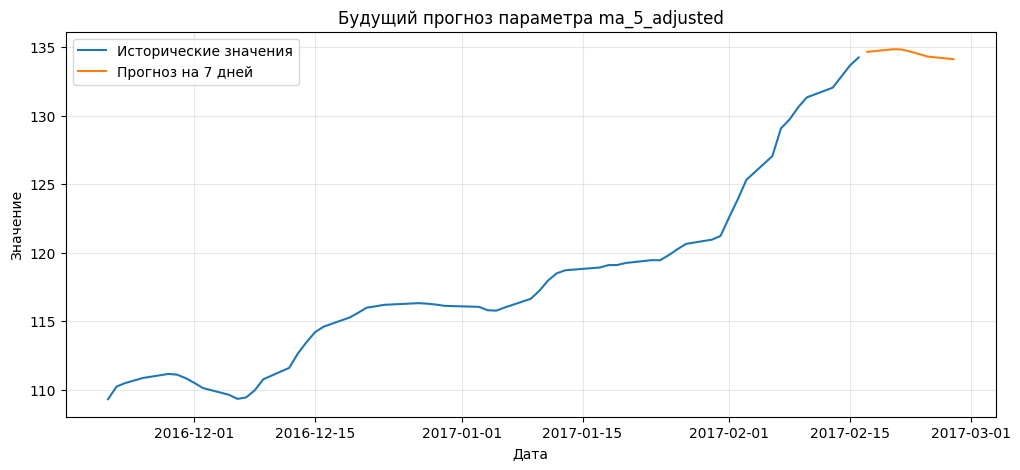

,Date,forecast_ma_5_adjusted
0,2017-02-17,134.6638
1,2017-02-20,134.8594
2,2017-02-21,134.8369
3,2017-02-22,134.6807
4,2017-02-23,134.5107
5,2017-02-24,134.3213
6,2017-02-27,134.1324


In [ ]:
history = forecast_df["ma_5_adjusted"].tolist()
future_steps = 7
future_predictions = []

for _ in range(future_steps):
    future_features = pd.DataFrame([{
        "current_value": history[-1],
        "lag_1": history[-2],
        "lag_2": history[-3],
        "lag_3": history[-4],
        "lag_5": history[-6],
        "ma_3": pd.Series(history[-3:]).mean(),
        "std_3": pd.Series(history[-3:]).std(),
        "ma_7": pd.Series(history[-7:]).mean(),
        "std_7": pd.Series(history[-7:]).std()
    }])

    next_pred = model.predict(future_features)[0]
    future_predictions.append(next_pred)
    history.append(next_pred)

future_dates = pd.bdate_range(
    start=forecast_df["Date"].max() + pd.Timedelta(days=1),
    periods=future_steps
)

future_df = pd.DataFrame({
    "Date": future_dates,
    "forecast_ma_5_adjusted": future_predictions
})

recent_actual = forecast_df.tail(60)

plt.figure(figsize=(12, 5))
plt.plot(recent_actual["Date"], recent_actual["ma_5_adjusted"], label="Исторические значения")
plt.plot(future_df["Date"], future_df["forecast_ma_5_adjusted"], label="Прогноз на 7 дней")
plt.title("Будущий прогноз параметра ma_5_adjusted")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

display(future_df.round(4))

## Практическая ячейка 8. Итоговое объяснение для начинающих и выводы для диплома

### Назначение ячейки

Последняя ячейка:

- переводит результаты модели в обычный язык;
- показывает, как описать использование ИИ в дипломе;
- добавляет `assert`-проверки для `Run all`.

### Краткая теория

В дипломе важно не просто показать код, а объяснить:

- какие данные использовались;
- какой показатель прогнозировался;
- какая модель обучалась;
- как проверялось качество;
- какой был результат.

Именно это превращает ноутбук в полноценный учебный AI-кейс.

### Как интерпретировать результат

Вы получите готовые выводы, которые можно использовать:

- в отчёте;
- в защите;
- в разделе диплома «Применение ИИ».

Также `assert`-проверки покажут, что ноутбук отрабатывает корректно.

In [ ]:
first_future_value = future_df.iloc[0]["forecast_ma_5_adjusted"]
last_future_value = future_df.iloc[-1]["forecast_ma_5_adjusted"]

print("ИТОГОВЫЕ ВЫВОДЫ")
print()
print("1. Для учебной задачи ИИ был выбран показатель ma_5_adjusted — 5-дневная скользящая средняя по adjusted.")
print("   Этот параметр построен на основе реальных финансовых данных и хорошо подходит для первого прогностического проекта.")
print()
print("2. Были созданы лаговые признаки и статистики по предыдущим дням.")
print("   Благодаря этому модель получила информацию о прошлом состоянии временного ряда.")
print()
print("3. В роли AI/ML-модели использована LinearRegression.")
print("   Модель обучалась на исторических данных и пыталась предсказать значение на следующий день.")
print()
print(f"4. Baseline: MAE = {baseline_mae:.4f}, RMSE = {baseline_rmse:.4f}, R² = {baseline_r2:.4f}")
print(f"5. LinearRegression: MAE = {model_mae:.4f}, RMSE = {model_rmse:.4f}, R² = {model_r2:.4f}")
print("   Если ошибки модели меньше baseline, значит использование машинного обучения оправдано.")
print()
print(f"6. Прогноз на первый будущий торговый день: {first_future_value:.4f}")
print(f"7. Прогноз на седьмой будущий торговый день: {last_future_value:.4f}")
print()
print("8. Для дипломного проекта студент может показать полный AI-цикл:")
print("   загрузка данных -> подготовка признаков -> обучение модели -> оценка качества -> прогноз будущих значений.")
print()
print("9. Ограничение подхода:")
print("   модель простая и учебная, поэтому в реальных финансовых системах её нужно усиливать более сложными алгоритмами и дополнительными данными.")
print()
print("10. Этот прогноз является учебным и не должен использоваться как инвестиционная рекомендация.")

assert len(feature_cols) == 9
assert len(X_train) > 0 and len(X_test) > 0
assert len(test_pred) == len(y_test)
assert len(future_df) == 7
assert future_df["forecast_ma_5_adjusted"].isna().sum() == 0
assert model_mae < baseline_mae
assert model_rmse < baseline_rmse

print("\nПРОВЕРКИ ПРОЙДЕНЫ УСПЕШНО")

ИТОГОВЫЕ ВЫВОДЫ

1. Для учебной задачи ИИ был выбран показатель ma_5_adjusted — 5-дневная скользящая средняя по adjusted.
   Этот параметр построен на основе реальных финансовых данных и хорошо подходит для первого прогностического проекта.

2. Были созданы лаговые признаки и статистики по предыдущим дням.
   Благодаря этому модель получила информацию о прошлом состоянии временного ряда.

3. В роли AI/ML-модели использована LinearRegression.
   Модель обучалась на исторических данных и пыталась предсказать значение на следующий день.

4. Baseline: MAE = 0.4711, RMSE = 0.6180, R² = 0.9901
5. LinearRegression: MAE = 0.2351, RMSE = 0.3174, R² = 0.9974
   Если ошибки модели меньше baseline, значит использование машинного обучения оправдано.

6. Прогноз на первый будущий торговый день: 134.6638
7. Прогноз на седьмой будущий торговый день: 134.1324

8. Для дипломного проекта студент может показать полный AI-цикл:
   загрузка данных -> подготовка признаков -> обучение модели -> оценка качеств

## Что студент должен вынести из этого занятия

После выполнения ноутбука студент должен понимать:

- как выбрать прогнозируемый финансовый параметр;
- зачем иногда лучше прогнозировать сглаженный показатель, а не сырой шумный ряд;
- как работают лаговые признаки;
- как проверять модель на будущем интервале;
- как интерпретировать MAE, RMSE и R²;
- как оформить ML-прогноз как часть дипломного проекта.

## Как это можно описать в дипломе

Пример формулировки:

> В дипломном проекте был реализован модуль прогнозирования финансового параметра `ma_5_adjusted`, рассчитанного на основе исторических данных акций Apple.  
> Для решения задачи использовалась модель машинного обучения Linear Regression.  
> На этапе подготовки данных были сформированы лаговые признаки и скользящие статистики, характеризующие поведение временного ряда.  
> Качество модели оценивалось на тестовой выборке по метрикам MAE, RMSE и R², а затем модель применялась для прогноза на будущие торговые дни.

## Что можно сделать следующим шагом

Дальнейшее развитие учебного проекта:

- сравнить несколько моделей машинного обучения;
- сделать прогноз не только сглаженного параметра, но и сырой цены `adjusted`;
- завернуть модель в API на FastAPI;
- сделать web-интерфейс прогноза;
- добавить базу данных и журнал сохранённых прогнозов;
